# Causal structure preservation pipeline

This notebook walks through the causal-structure preservation pipeline in a representative way.
It is intended for inspection and teaching; the frozen paper results live under `results/`.

After **Stage I (data)** and **Stage II (encoding)** the pipeline splits into two separate paths:

* **Raw-neuron path** — encoded spikes are immediately reduced to one scalar per variable per sample, then fed to causal discovery.
* **Assembly path** — the same encoded spikes first go through assembly formation (k-WTA competition + Hebbian plasticity), then through an assembly-level readout, then to causal discovery.

Both paths use identical discovery settings so that any difference in the recovered DAG is attributable solely to the representational transformation.

The notebook runs both paths for **two encoding schemes**: Bernoulli and deterministic-k.

In [1]:
from pathlib import Path
import contextlib, io, sys

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src").exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError("Run from repo root or notebooks/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.alzheimers.validate_alzheimers import generate_alzheimers_data
from src.validation.observational.dag_comparison import compare_dags
from notebooks.viz_helpers import (
    encode,
    neuron_readout,
    assembly_formation,
    assembly_readout,
    discover,
    draw_dag,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120


## Configuration

This notebook mirrors the frozen Alzheimer single-run paper setup. It uses the
same seed, sample size, deterministic-k step, assembly settings, and PC discovery
path as `experiments/generate_single_run_table_artifacts.py` for the Alzheimer
row in Table 2.

The Bernoulli panels remain as a visual contrast, but the deterministic-k panels
are the paper-aligned preservation case expected to recover all Alzheimer edges.


In [2]:
SEED                 = 42
N_SAMPLES            = 5000
NEURONS_PER_VAR      = 1666
ASSEMBLY_K           = 100
DETERMINISTIC_K_STEP = 10
N_TRAIN              = 200
N_PRESENTATIONS      = 3
BETA                 = 0.05
METHOD               = "pc"
ALPHA_PC             = 0.05

# Frozen single-run Bernoulli baseline used by the paper artifact generator.
BERN_POSITIVE_PROB   = 0.30
BERN_NEGATIVE_PROB   = 0.10

VAR_NAMES = [
    "APOE4",
    "PhysicalActivity",
    "Diet",
    "Cholesterol",
    "Inflammation",
    "SleepQuality",
    "Education",
    "Amyloid",
    "Tau",
    "CognitiveDecline",
]

POSITIVE_VALUES_MAP = {
    "APOE4": {"Carrier"},
    "PhysicalActivity": {"Sedentary"},
    "Diet": {"Poor"},
    "Cholesterol": {"High"},
    "Inflammation": {"High"},
    "SleepQuality": {"Poor"},
    "Education": {"Low"},
    "Amyloid": {"High"},
    "Tau": {"High"},
    "CognitiveDecline": {"Decline"},
}

DAG_POS = {
    # Hierarchical layout: lifestyle/genetic drivers -> mediators -> pathology -> outcome
    "APOE4": (-1.45, 1.65),
    "PhysicalActivity": (-0.45, 1.65),
    "Diet": (0.55, 1.65),
    "Education": (1.45, 1.65),
    "Cholesterol": (-1.05, 0.65),
    "Inflammation": (0.0, 0.65),
    "SleepQuality": (1.05, 0.65),
    "Amyloid": (-0.6, -0.45),
    "Tau": (0.6, -0.45),
    "CognitiveDecline": (0.0, -1.6),
}

NODE_R = 0.22
LABEL_FS = 7.2
TITLE_FS = 10
WRAP = {
    "PhysicalActivity": "Physical\nActivity",
    "SleepQuality": "Sleep\nQuality",
    "CognitiveDecline": "Cognitive\nDecline",
}


## Stage I — SCM data generation

In [3]:
# Stage I.A: SCM data and methodology
df, GT_EDGES = generate_alzheimers_data(n_patients=N_SAMPLES, seed=SEED)

print('Data were synthetically generated from a ground-truth')
print('Structural Causal Model (SCM) with 10 variables and')
print('10 causal edges, following the Alzheimer disease domain.')
print()
print('Discovery algorithms attempt to recover this')
print('ground-truth DAG from encoded neural representations.')
print()
print(f'Notebook configuration: seed={SEED}, n_samples={N_SAMPLES}, method={METHOD}, alpha={ALPHA_PC}')
print()
print('Ground-truth causal edges:')
for s, t in GT_EDGES:
    print(f'  {s} -> {t}')



GENERATING ALZHEIMER PATIENT DATA
  Cohort size: 5000 patients
  Variables: 10 (APOE4, PhysicalActivity, Diet, Cholesterol, Inflammation, SleepQuality, Education, Amyloid, Tau, CognitiveDecline)

  Clinical Distribution:
    APOE4 Carriers: 1515 (30.3%)
    High Cholesterol: 1757 (35.1%)
    High Inflammation: 1245 (24.9%)
    Poor Sleep: 1999 (40.0%)
    Low Education: 1770 (35.4%)
    High Amyloid: 2531 (50.6%)
    Cognitive Decline: 2095 (41.9%)

  Ground Truth Causal Edges:
    APOE4 -> Amyloid
    PhysicalActivity -> Amyloid
    Diet -> Tau
    Cholesterol -> Amyloid
    Inflammation -> Amyloid
    Inflammation -> Tau
    SleepQuality -> Tau
    Amyloid -> CognitiveDecline
    Tau -> CognitiveDecline
    Education -> CognitiveDecline
Data were synthetically generated from a ground-truth
Structural Causal Model (SCM) with 10 variables and
10 causal edges, following the Alzheimer disease domain.

Discovery algorithms attempt to recover this
ground-truth DAG from encoded neural repr

## Stage II — Symbolic-to-spike encoding

The same observations are encoded twice: once with **Bernoulli** (stochastic, overlap-prone)
and once with **deterministic-k** (fixed value-specific active indices, low overlap).
Both produce an `N_SAMPLES × (len(VAR_NAMES) × NEURONS_PER_VAR)` binary spike matrix.

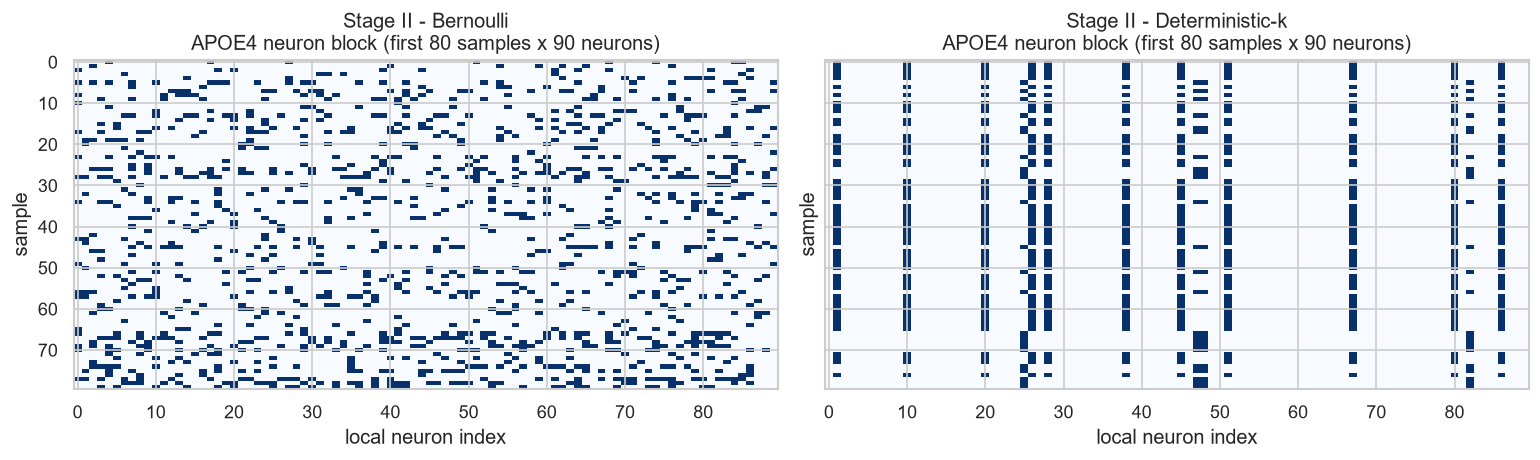

In [6]:
bern_neural, bern_stim_idx = encode(
    df,
    deterministic_k=False,
    var_names=VAR_NAMES,
    assembly_k=ASSEMBLY_K,
    neurons_per_var=NEURONS_PER_VAR,
    seed=SEED,
    positive_values_map=POSITIVE_VALUES_MAP,
    positive_prob=BERN_POSITIVE_PROB,
    negative_prob=BERN_NEGATIVE_PROB,
    k_step=DETERMINISTIC_K_STEP,
)
detk_neural, detk_stim_idx = encode(
    df,
    deterministic_k=True,
    var_names=VAR_NAMES,
    assembly_k=ASSEMBLY_K,
    neurons_per_var=NEURONS_PER_VAR,
    seed=SEED,
    positive_values_map=POSITIVE_VALUES_MAP,
    k_step=DETERMINISTIC_K_STEP,
)

# Show spike block for first variable under both encodings
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, neural) in zip(axes, [("Bernoulli", bern_neural), ("Deterministic-k", detk_neural)]):
    block = neural[:80, :90]
    ax.imshow(block, aspect="auto", interpolation="nearest", cmap="Blues")
    ax.set_title(f"Stage II - {label}\n{VAR_NAMES[0]} neuron block (first 80 samples x 90 neurons)")
    ax.set_xlabel("local neuron index")
    ax.set_ylabel("sample")
plt.tight_layout()
plt.show()


---
## After encoding: two parallel paths

| | Raw-neuron path | Assembly path |
|---|---|---|
| Input | encoded spike matrix | encoded spike matrix |
| Stage III / IV | **direct readout (pool-mean over local neuron block)** (pool mean or positive-subset mean; in parallel with assembly formation) | **assembly formation** (k-WTA + Hebbian plasticity) |
| Stage V | — | **assembly readout** (population averaging over connectomes) |
| Output | neuron feature DataFrame | assembly feature DataFrame |
| Stage VI (shared) | **causal discovery** (PC or GES) | **causal discovery** (PC or GES) |

Both paths end at the same discovery and comparison step with identical algorithm settings.

## Stage III — Raw-neuron path (direct readout)

Each variable is reduced to one scalar per sample directly from its local neuron block (no assembly step).

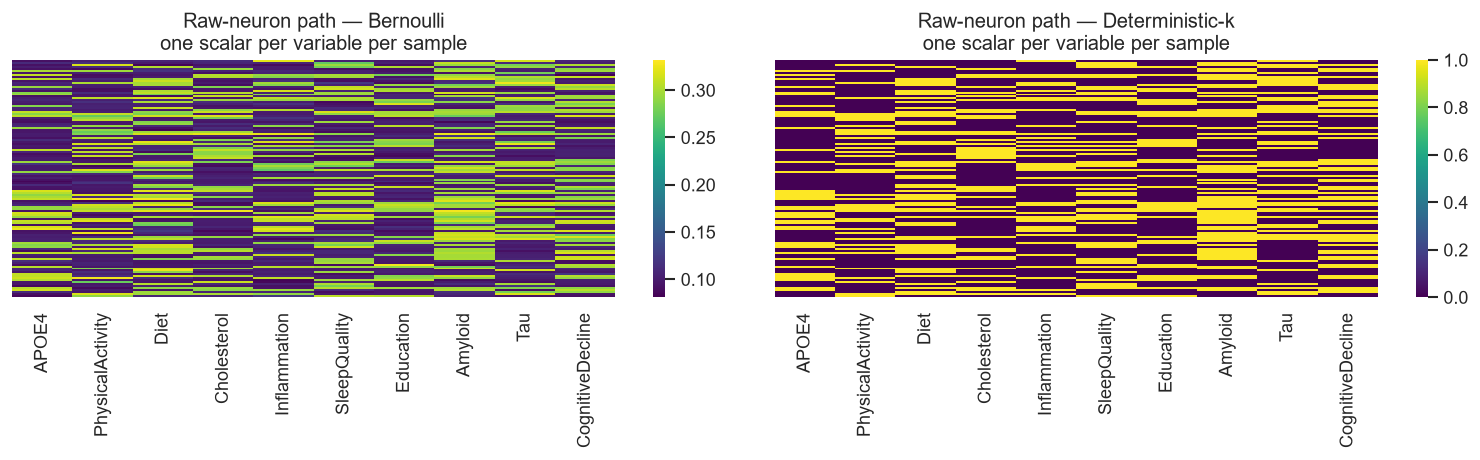

In [7]:
bern_neuron_df = neuron_readout(
    bern_neural,
    var_names=VAR_NAMES,
    neurons_per_var=NEURONS_PER_VAR,
    positive_values_map=POSITIVE_VALUES_MAP,
    stim_idx=bern_stim_idx,
    deterministic_k=False,
)
detk_neuron_df = neuron_readout(
    detk_neural,
    var_names=VAR_NAMES,
    neurons_per_var=NEURONS_PER_VAR,
    positive_values_map=POSITIVE_VALUES_MAP,
    stim_idx=detk_stim_idx,
    deterministic_k=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, df_feat) in zip(axes, [("Bernoulli", bern_neuron_df), ("Deterministic-k", detk_neuron_df)]):
    sns.heatmap(
        df_feat.head(120),
        ax=ax,
        cmap="viridis",
        cbar=True,
        xticklabels=True,
        yticklabels=False,
    )
    ax.set_title(f"Raw-neuron path — {label}\none scalar per variable per sample")
plt.tight_layout()
plt.show()


## Stage IV — Assembly path: formation

Encoded activity is projected into Brain areas for `N_PRESENTATIONS` rounds.
k-WTA competition keeps only the top-k active neurons per projection; Hebbian
plasticity strengthens co-activated connections. The bar chart shows final
assembly support size `w` (how many neurons have ever fired in each area).

Forming assemblies for Bernoulli encoding ...
Forming assemblies for Deterministic-k encoding ...


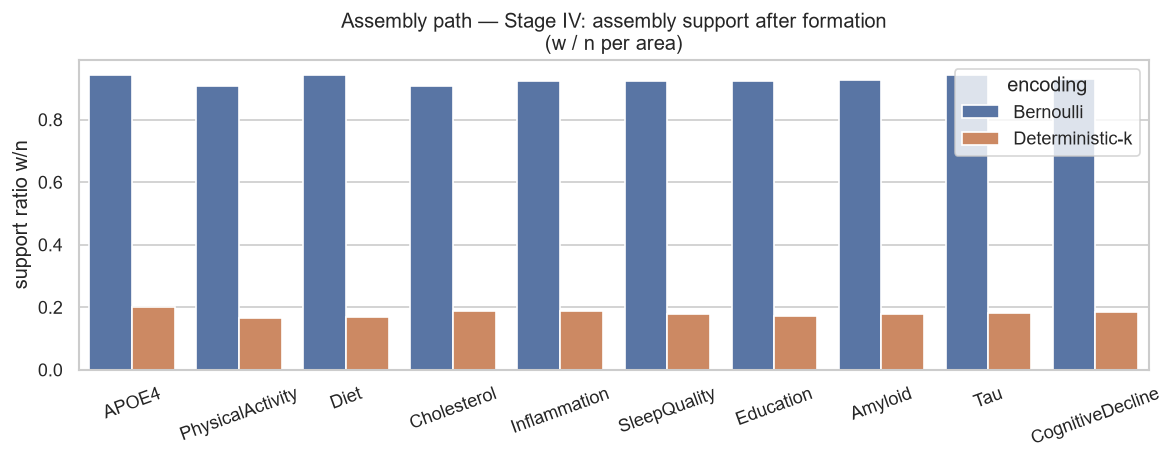

encoding,Bernoulli,Deterministic-k
variable,,
APOE4,1569,334
Amyloid,1541,297
Cholesterol,1511,314
CognitiveDecline,1548,308
Diet,1572,283
Education,1539,286
Inflammation,1537,313
PhysicalActivity,1514,277
SleepQuality,1539,295


In [8]:
print("Forming assemblies for Bernoulli encoding ...")
bern_brain = assembly_formation(
    bern_neural,
    var_names=VAR_NAMES,
    neurons_per_var=NEURONS_PER_VAR,
    assembly_k=ASSEMBLY_K,
    beta=BETA,
    seed=SEED,
    n_train=N_TRAIN,
    n_presentations=N_PRESENTATIONS,
)
print("Forming assemblies for Deterministic-k encoding ...")
detk_brain = assembly_formation(
    detk_neural,
    var_names=VAR_NAMES,
    neurons_per_var=NEURONS_PER_VAR,
    assembly_k=ASSEMBLY_K,
    beta=BETA,
    seed=SEED,
    n_train=N_TRAIN,
    n_presentations=N_PRESENTATIONS,
)

rows = []
for label, brain in [("Bernoulli", bern_brain), ("Deterministic-k", detk_brain)]:
    for var in VAR_NAMES:
        area = brain.area_by_name[var]
        rows.append(
            {
                "encoding": label,
                "variable": var,
                "support_w": area.w,
                "support_ratio": area.w / area.n,
            }
        )
support_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=support_df, x="variable", y="support_ratio", hue="encoding", ax=ax)
ax.set_title("Assembly path — Stage IV: assembly support after formation\n(w / n per area)")
ax.set_ylabel("support ratio w/n")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
display(support_df.pivot(index="variable", columns="encoding", values="support_w"))


## Stage V — Assembly path: readout

The formed Brain is reused to extract one assembly-level scalar per variable per sample
via population averaging over learned stimulus-area connectomes.

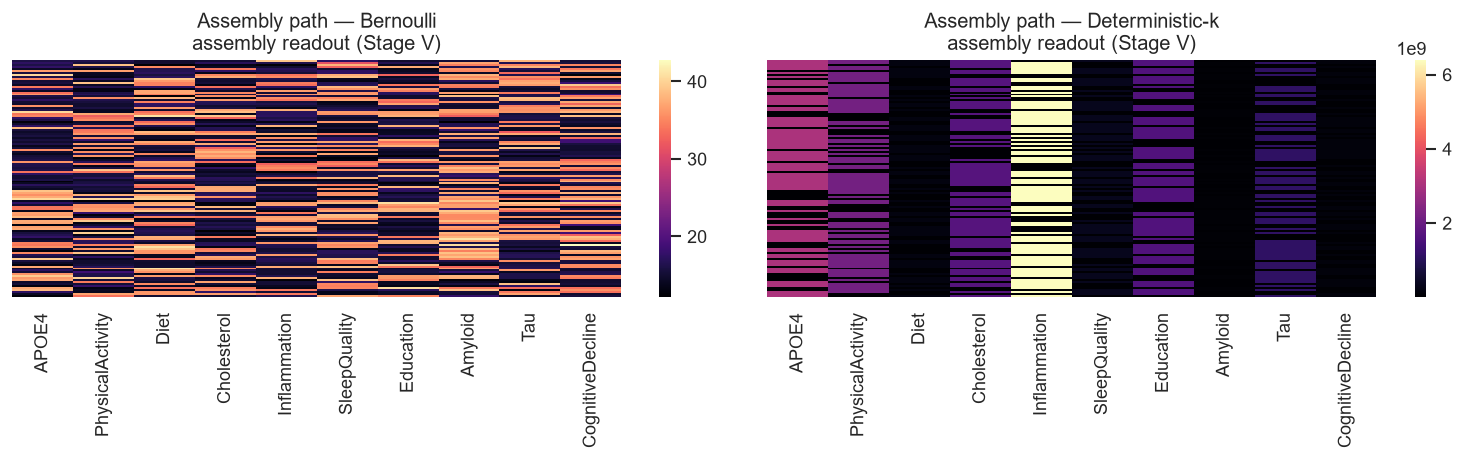

In [9]:
bern_assembly_df = assembly_readout(
    bern_neural,
    bern_brain,
    var_names=VAR_NAMES,
    neurons_per_var=NEURONS_PER_VAR,
)
detk_assembly_df = assembly_readout(
    detk_neural,
    detk_brain,
    var_names=VAR_NAMES,
    neurons_per_var=NEURONS_PER_VAR,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, df_feat) in zip(axes, [("Bernoulli", bern_assembly_df), ("Deterministic-k", detk_assembly_df)]):
    sns.heatmap(
        df_feat.head(120),
        ax=ax,
        cmap="magma",
        cbar=True,
        xticklabels=True,
        yticklabels=False,
    )
    ax.set_title(f"Assembly path — {label}\nassembly readout (Stage V)")
plt.tight_layout()
plt.show()


---
## Stage VI — Convergence: causal discovery and comparison

Both paths are now represented as DataFrames with one scalar per variable per sample.
The same `METHOD` (PC or GES) is applied to both under identical settings.

In [10]:
bern_neuron_edges = discover(
    bern_neuron_df, var_names=VAR_NAMES, method=METHOD, alpha=ALPHA_PC, strict=False
)
bern_assembly_edges = discover(
    bern_assembly_df, var_names=VAR_NAMES, method=METHOD, alpha=ALPHA_PC, strict=False
)
detk_neuron_edges = discover(
    detk_neuron_df, var_names=VAR_NAMES, method=METHOD, alpha=ALPHA_PC, strict=False
)
detk_assembly_edges = discover(
    detk_assembly_df, var_names=VAR_NAMES, method=METHOD, alpha=ALPHA_PC, strict=False
)

rows = []
for label, ne, ae in [
    ("Bernoulli", bern_neuron_edges, bern_assembly_edges),
    ("Deterministic-k", detk_neuron_edges, detk_assembly_edges),
]:
    nm = compare_dags(GT_EDGES, ne, VAR_NAMES)
    am = compare_dags(GT_EDGES, ae, VAR_NAMES)
    rows.append(
        {
            "encoding": label,
            "neuron_edges": len(ne),
            "neuron_f1": round(nm["f1"], 3),
            "neuron_precision": round(nm["precision"], 3),
            "neuron_recall": round(nm["recall"], 3),
            "neuron_tp": nm["tp"],
            "neuron_fp": nm["fp"],
            "neuron_fn": nm["fn"],
            "assembly_edges": len(ae),
            "assembly_f1": round(am["f1"], 3),
            "assembly_precision": round(am["precision"], 3),
            "assembly_recall": round(am["recall"], 3),
            "assembly_tp": am["tp"],
            "assembly_fp": am["fp"],
            "assembly_fn": am["fn"],
        }
    )

summary_df = pd.DataFrame(rows)

print("Raw-neuron path metrics")
display(
    summary_df[[
        "encoding",
        "neuron_edges", "neuron_tp", "neuron_fp", "neuron_fn",
        "neuron_precision", "neuron_recall", "neuron_f1",
    ]]
)

print("Assembly path metrics")
display(
    summary_df[[
        "encoding",
        "assembly_edges", "assembly_tp", "assembly_fp", "assembly_fn",
        "assembly_precision", "assembly_recall", "assembly_f1",
    ]]
)


Raw-neuron path metrics


,encoding,neuron_edges,neuron_tp,neuron_fp,neuron_fn,neuron_precision,neuron_recall,neuron_f1
0,Bernoulli,10,10,0,0,1.0,1.0,1.0
1,Deterministic-k,10,10,0,0,1.0,1.0,1.0


Assembly path metrics


,encoding,assembly_edges,assembly_tp,assembly_fp,assembly_fn,assembly_precision,assembly_recall,assembly_f1
0,Bernoulli,11,6,5,4,0.545,0.6,0.571
1,Deterministic-k,10,10,0,0,1.000,1.0,1.000


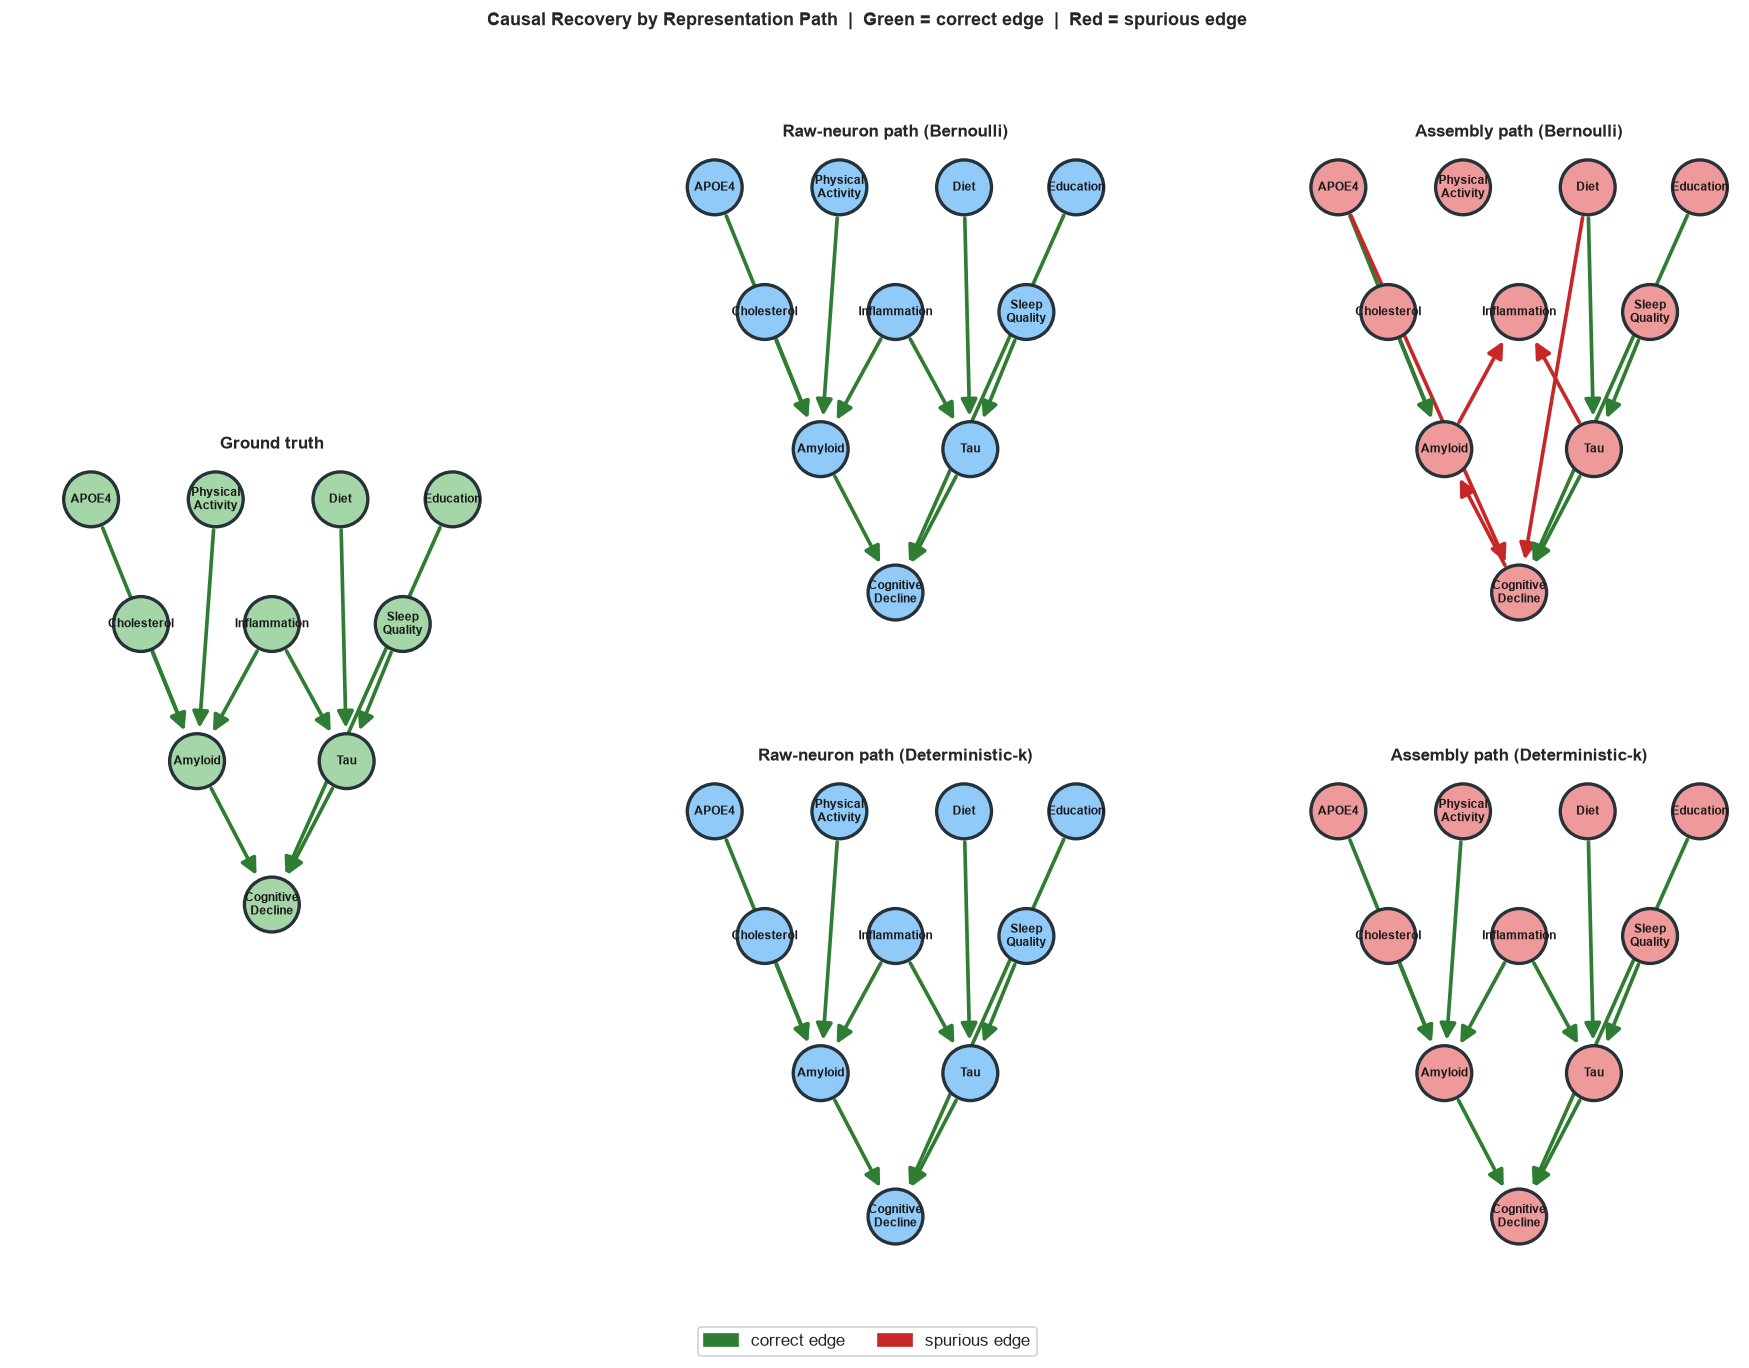

In [11]:
fig = plt.figure(figsize=(19, 11.5))
fig.subplots_adjust(bottom=0.08)
gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 1.0, 1.0], hspace=0.30)

# Keep the previous layout: one left slot for GT, 2x2 right panels.
ax_gt_slot = fig.add_subplot(gs[:, 0])
ax_gt_slot.axis("off")

ax_bern_raw = fig.add_subplot(gs[0, 1])
ax_bern_assm = fig.add_subplot(gs[0, 2])
ax_detk_raw = fig.add_subplot(gs[1, 1])
ax_detk_assm = fig.add_subplot(gs[1, 2])

# Create a centered GT axis inside the left slot, with same size as right DAG panels.
fig.canvas.draw()
slot = ax_gt_slot.get_position()
ref = ax_bern_raw.get_position()

gt_w = min(ref.width, slot.width)
gt_h = min(ref.height, slot.height)
gt_x = slot.x0 + (slot.width - gt_w) / 2.0
gt_y = slot.y0 + (slot.height - gt_h) / 2.0

ax_gt = fig.add_axes([gt_x, gt_y, gt_w, gt_h])

draw_dag(
    ax_gt,
    GT_EDGES,
    "Ground truth",
    "#A5D6A7",
    var_names=VAR_NAMES,
    dag_pos=DAG_POS,
    node_r=NODE_R,
    label_fs=LABEL_FS,
    title_fs=TITLE_FS,
    wrap_labels=WRAP,
    gt_edges=GT_EDGES,
)

draw_dag(
    ax_bern_raw,
    bern_neuron_edges,
    "Raw-neuron path (Bernoulli)",
    "#90CAF9",
    var_names=VAR_NAMES,
    dag_pos=DAG_POS,
    node_r=NODE_R,
    label_fs=LABEL_FS,
    title_fs=TITLE_FS,
    wrap_labels=WRAP,
    gt_edges=GT_EDGES,
)
draw_dag(
    ax_bern_assm,
    bern_assembly_edges,
    "Assembly path (Bernoulli)",
    "#EF9A9A",
    var_names=VAR_NAMES,
    dag_pos=DAG_POS,
    node_r=NODE_R,
    label_fs=LABEL_FS,
    title_fs=TITLE_FS,
    wrap_labels=WRAP,
    gt_edges=GT_EDGES,
)
draw_dag(
    ax_detk_raw,
    detk_neuron_edges,
    "Raw-neuron path (Deterministic-k)",
    "#90CAF9",
    var_names=VAR_NAMES,
    dag_pos=DAG_POS,
    node_r=NODE_R,
    label_fs=LABEL_FS,
    title_fs=TITLE_FS,
    wrap_labels=WRAP,
    gt_edges=GT_EDGES,
)
draw_dag(
    ax_detk_assm,
    detk_assembly_edges,
    "Assembly path (Deterministic-k)",
    "#EF9A9A",
    var_names=VAR_NAMES,
    dag_pos=DAG_POS,
    node_r=NODE_R,
    label_fs=LABEL_FS,
    title_fs=TITLE_FS,
    wrap_labels=WRAP,
    gt_edges=GT_EDGES,
)

fig.suptitle(
    "Causal Recovery by Representation Path  |  Green = correct edge  |  Red = spurious edge",
    fontsize=11,
    fontweight="bold",
)
import matplotlib.patches as mpatches
_handles = [
    mpatches.Patch(color="#2E7D32", label="correct edge"),
    mpatches.Patch(color="#C62828", label="spurious edge"),
]
fig.legend(
    handles=_handles,
    loc="lower center",
    ncol=2,
    fontsize=10,
    framealpha=0.85,
    bbox_to_anchor=(0.5, 0.0),
)
# Remove all legends from all axes
for ax in [ax_gt, ax_bern_raw, ax_bern_assm, ax_detk_raw, ax_detk_assm]:
    if ax.get_legend():
        ax.get_legend().remove()

plt.show()
